In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy import config
import cartopy.feature as cfeature
from cartopy.vector_transform import vector_scalar_to_grid
from matplotlib.axes import Axes
import metpy
import pint
import metpy.calc as mpcalc
from metpy.cbook import get_test_data
from metpy.units import units
import scipy as sp
from scipy.interpolate import RectBivariateSpline
import xarray as xr
from lagranto import Tra
import math
import datetime
from scipy.ndimage import rotate
import time
import iris
from iris.analysis.cartography import rotate_pole, rotate_winds
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
from matplotlib.animation import FuncAnimation
import matplotlib.colors as mcolors

/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-packages/pyproj/__init__.py:91: UserWarning: Valid PROJ data directory not found. Either set the path using the environmental variable PROJ_DATA (PROJ 9.1+) | PROJ_LIB (PROJ<9.1) or with `pyproj.datadir.set_data_dir`.
  warnings.warn(str(err))


In [2]:
# 17, 77, 49, 53 53, 

In [3]:
%run GEOS5functions.py
%matplotlib inline 

In [4]:
# Retrieve the list of all storms using the getallstorms function
stormlist = getallstorms()

# Set the current storm index to ???
currentstorm = 17

In [5]:
starttime = stormlist[3][currentstorm]
endtime   = stormlist[4][currentstorm]
lat1  = stormlist[5][currentstorm]
lat2  = stormlist[6][currentstorm]
lon1  = stormlist[7][currentstorm]
lon2  = stormlist[8][currentstorm]

timesel = slice(starttime,endtime)
extended_timesel = slice(starttime - datetime.timedelta(days=5) ,endtime + datetime.timedelta(days=5))
degbuffer = 20
latsel = slice(lat1-degbuffer,lat2+degbuffer)
lonsel = slice(lon1-degbuffer,lon2+degbuffer)

In [6]:
timesel

slice(datetime.datetime(2006, 8, 18, 10, 0), datetime.datetime(2006, 8, 30, 15, 0), None)

In [7]:
extended_timesel

slice(datetime.datetime(2006, 8, 13, 10, 0), datetime.datetime(2006, 9, 4, 15, 0), None)

In [8]:
stormname = stormlist[1][currentstorm][0:9]
print(stormname)

atl06tc01


In [9]:
stormtraj = np.load('/home/modares/TC/trajectory/' + str(stormname)+'.npz')
minpres = stormtraj['minpres']
timee = stormtraj['time']
minplat = stormtraj['minplat']
minplon = stormtraj['minplon']

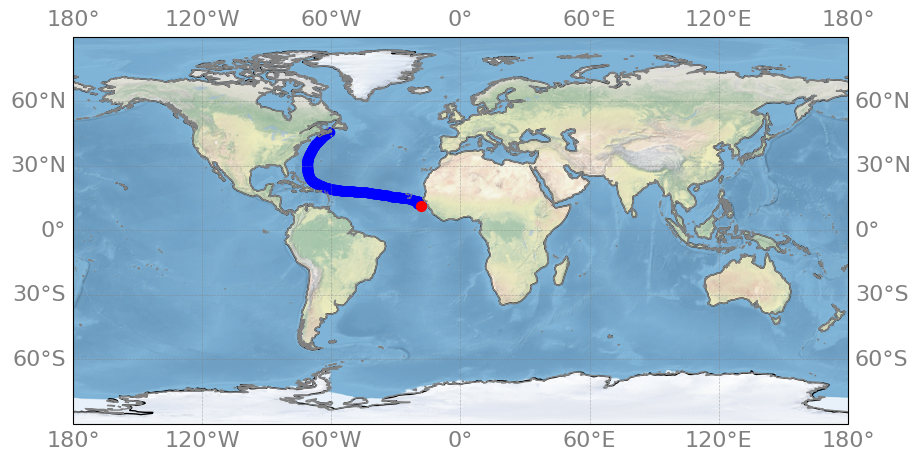

In [10]:
fig = plt.figure(figsize=(10,6))
crs0 = ccrs.PlateCarree(central_longitude=0)
ax = fig.add_subplot(1, 1, 1, projection=crs0)
#ax.set_extent([lon[0], lon[-1], lat[0], lat[-1]], crs=crs0)

#####

#ax.set_extent([60, 120, -20, 20], crs=crs0)
ax.stock_img()
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.OCEAN)

ax.add_feature(cfeature.LAND)
#####

ax.coastlines()
ax.coastlines('50m', color='gray', edgecolor='white')
gl = ax.gridlines(crs=crs0, draw_labels=True,
          linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.xlabel_style = {'size':16,'color':'gray'}
gl.ylabel_style = {'size':16,'color':'gray'}

# Plot all points
plt.scatter(minplon, minplat, color='blue', transform=ccrs.PlateCarree())

# Highlight first point in red
plt.scatter(minplon[0], minplat[0], color='red', s=50, zorder=5, transform=ccrs.PlateCarree())

plt.show()

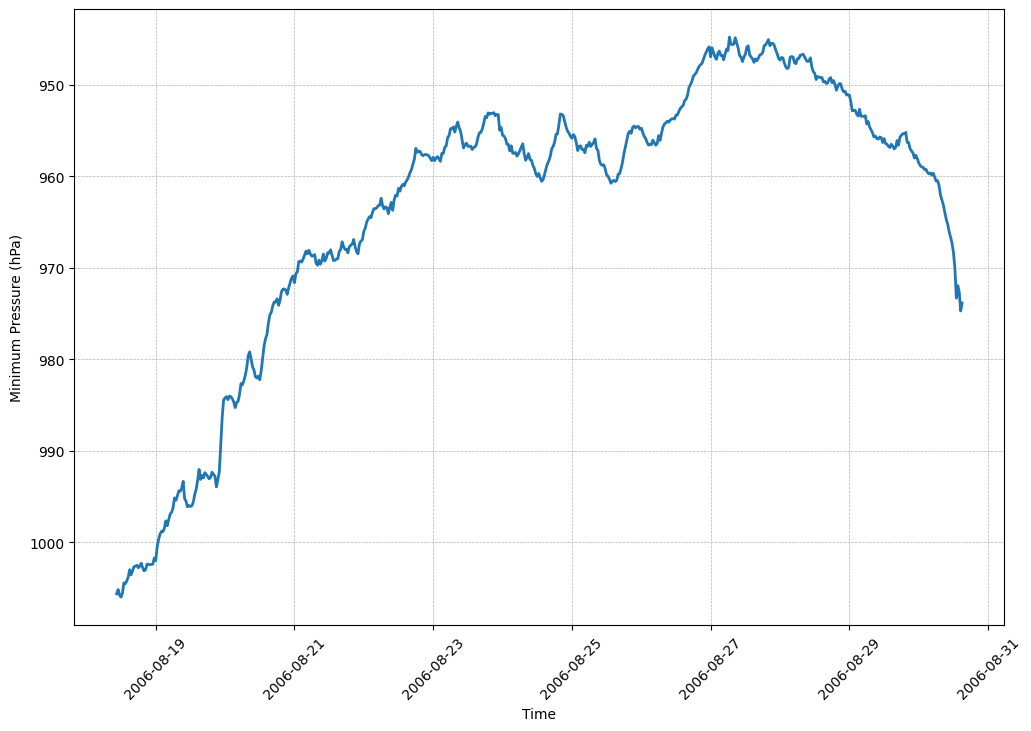

In [11]:
minpres = stormtraj['minpres']
timee = stormtraj['time']

fig, ax = plt.subplots(figsize=(12, 8))

plt.plot(timee, minpres/100,linewidth=2 )

plt.xlabel('Time')
plt.ylabel('Minimum Pressure (hPa)')

plt.grid(True, which='both', linestyle='--', linewidth=0.5)

ax.invert_yaxis()
plt.xticks(rotation=45)

#plt.savefig('npc06tc01_intensity.png', bbox_inches='tight', transparent=True)


plt.show()

In [13]:
#variables listed here: https://opendap.nccs.nasa.gov/dods/OSSE/G5NR/Ganymed/7km/0.0625_deg/inst

# List of variable names to retrieve from the dataset
varvec = ['U', 'V', 'SO4', 'CLOUD', 'PL', 'T', 'DELP', 'SO2', 'SO4', 'BCPHOBIC','BCPHILIC', 'H', 'W']

# Iterate over each variable name in varvec
for vind in range(len(varvec)):
    # Construct the URL for accessing the dataset corresponding to the current variable
    url = 'https://opendap.nccs.nasa.gov/dods/OSSE/G5NR/Ganymed/7km/0.0625_deg/inst/inst30mn_3d_' + varvec[vind] + '_Nv'
    
    # Open the dataset for the current variable based on the variable name
    if varvec[vind] == 'U':
        dsu = xr.open_dataset(url)  # Open dataset for 'U' (zonal wind component)
    if varvec[vind] == 'V':
        dsv = xr.open_dataset(url)  # Open dataset for 'V' (meridional wind component)
    if varvec[vind] == 'SO2':
        dsso4 = xr.open_dataset(url)  # Open dataset for 'DELP' (surface pressure and pressure thickness)
    if varvec[vind] == 'CLOUD':
        dscloud = xr.open_dataset(url)
    if varvec[vind] == 'PL':
        dspl = xr.open_dataset(url)
    if varvec[vind] == 'T':
        dst = xr.open_dataset(url)
    if varvec[vind] == 'DELP':
        dsdelp = xr.open_dataset(url)
    if varvec[vind] == 'H':
        dsh = xr.open_dataset(url)

# Print a success message indicating that the datasets have been read successfully
print('success reading')

# URL for accessing the land mask dataset
landurl = 'https://opendap.nccs.nasa.gov/dods/OSSE/G5NR/Ganymed/7km/0.0625_deg/const/const_2d_asm_Nx'
# Open the land mask dataset
dsland = xr.open_dataset(landurl)

# Display the land mask dataset information


/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-packages/xarray/coding/times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)
/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-packages/xarray/coding/times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)
/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-pack

success reading


/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-packages/xarray/coding/times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)


In [14]:
lev = dsu['lev'] 
variable = 'so2'
time = dsso4['time'].sel(time= extended_timesel )
so4 = dsso4[variable].sel(time= extended_timesel )
delp = dsdelp['delp'].sel(time= extended_timesel )

In [15]:
dsso4

<xarray.Dataset> Size: 175TB
Dimensions:  (time: 36576, lev: 72, lat: 2881, lon: 5760)
Coordinates:
  * time     (time) datetime64[ns] 293kB 2005-05-15T21:30:00.000003 ... 2007-...
  * lev      (lev) float64 576B 1.0 2.0 3.0 4.0 5.0 ... 68.0 69.0 70.0 71.0 72.0
  * lat      (lat) float64 23kB -90.0 -89.94 -89.88 -89.81 ... 89.88 89.94 90.0
  * lon      (lon) float64 46kB -180.0 -179.9 -179.9 ... 179.8 179.9 179.9
Data variables:
    so2      (time, lev, lat, lon) float32 175TB ...
Attributes:
    title:                3d,30-Minute,Instantaneous,Model-Level,Full Resolut...
    Conventions:          COARDS\nGrADS
    dataType:             Grid
    history:              Mon Nov 03 10:17:09 UTC 2025 : imported by GrADS Da...
    extra_das_attribute:  This is an example of metadata added using a supple...

In [16]:
dsh['h'].sel(lev= 38).isel(time = 36500, lat = 100, lon =100).values

array(14758.168, dtype=float32)

In [17]:
extended_timesel

slice(datetime.datetime(2006, 8, 13, 10, 0), datetime.datetime(2006, 9, 4, 15, 0), None)

In [18]:
timesel = timee
len(timesel)

586

In [19]:
bufferrr = 2.5

In [20]:
first_value = minplat[0]  
last_value = minplat[-1]  

# Create arrays of 48 elements with the first and last values
prefix_array = np.full(240, first_value)
suffix_array = np.full(240, last_value)

# Concatenate the arrays
extended_minplat = np.concatenate([prefix_array, minplat, suffix_array])
extended_minplat.size

1066

In [21]:
first_value = minplon[0]  
last_value = minplon[-1]  

# Create arrays of 48 elements with the first and last values
prefix_array = np.full(240, first_value)
suffix_array = np.full(240, last_value)

# Concatenate the arrays
extended_minplon = np.concatenate([prefix_array, minplon, suffix_array])
extended_minplon.size

1066

In [22]:
extended_timee = dsso4['time'].sel(time= extended_timesel) 

In [23]:
extended_timee

<xarray.DataArray 'time' (time: 1066)> Size: 9kB
array(['2006-08-13T10:30:00.000000000', '2006-08-13T11:00:00.000003000',
       '2006-08-13T11:29:59.999997000', ..., '2006-09-04T14:00:00.000003000',
       '2006-09-04T14:29:59.999997000', '2006-09-04T15:00:00.000000000'],
      shape=(1066,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 9kB 2006-08-13T10:30:00 ... 2006-09-04T15:...
Attributes:
    grads_dim:      t
    grads_mapping:  linear
    grads_size:     36576
    grads_min:      21:30z15may2005
    grads_step:     30mn
    long_name:      time
    minimum:        21:30z15may2005
    maximum:        21z16jun2007
    resolution:     0.020833334

In [24]:

u_values, v_values, delp_values, so4_values = extract_values_with_buffer(
    dsv, dsu, delp, so4, extended_minplat, extended_minplon, extended_timee, lev, buffer = bufferrr
)



In [25]:
dxlow = distance(u_values[1].isel(lat = 0, lev =71).coords['lat'].values,
              u_values[1].isel(lon = 0, lev =71).coords['lon'].values,
              u_values[1].isel(lat = 0, lev =71).coords['lat'].values,
              u_values[1].isel(lon = -1, lev =71).coords['lon'].values) / u_values[1].sizes['lon'] 

dxhigh = distance(u_values[1].isel(lat = -1, lev =71).coords['lat'].values,
              u_values[1].isel(lon = 0, lev =71).coords['lon'].values,
              u_values[1].isel(lat = -1, lev =71).coords['lat'].values,
              u_values[1].isel(lon = -1, lev =71).coords['lon'].values) / u_values[1].sizes['lon'] 

dyleft = distance(u_values[1].isel(lat = 0, lev =71).coords['lat'].values,
              u_values[1].isel(lon = 0, lev =71).coords['lon'].values,
              u_values[1].isel(lat = -1, lev =71).coords['lat'].values,
              u_values[1].isel(lon = 0, lev =71).coords['lon'].values) / u_values[1].sizes['lon']

dyright = dyleft

In [26]:
import numpy as np
import xarray as xr
from concurrent.futures import ProcessPoolExecutor

def calculate_flux(delp, u, v, so4, dyright, dyleft, dxhigh, dxlow, g_inv):
    flux_east = (-1 * delp * dyright * u * so4 * g_inv).isel(lon=-1).sum(dim=['lat'])
    flux_west = (delp * dyleft * u * so4 * g_inv).isel(lon=0).sum(dim=['lat'])
    flux_north = (-1 * delp * dxhigh * v * so4 * g_inv).isel(lat=-1).sum(dim=['lon'])
    flux_south = (delp * dxlow * v * so4 * g_inv).isel(lat=0).sum(dim=['lon'])
    return flux_east + flux_west + flux_north + flux_south

def calculate_mass(delp, so4, dyright, dx_avg, g_inv):
    return ( so4 ).mean(dim=['lon', 'lat'])

def calculate_total_flux_optimized(delp_values, u_values, v_values, so4_values, 
                                   dyright, dyleft, dxhigh, dxlow, g=9.81, dt=1800):
    """
    Corrected and optimized version of the total flux calculation function for list inputs.
    """
    dx_avg = (dxhigh + dxlow) / 2
    g_inv = 1 / g

    total_flux = []
    mass_changes = []
    
    # Use ProcessPoolExecutor for parallel processing
    with ProcessPoolExecutor() as executor:
        futures = []
        for i in range(len(delp_values)-1):
            # Submit tasks for flux and mass calculation for both current and next time step
            futures.append(executor.submit(calculate_flux, delp_values[i], u_values[i], v_values[i], so4_values[i], 
                                           dyright, dyleft, dxhigh, dxlow, g_inv))
            futures.append(executor.submit(calculate_mass, delp_values[i], so4_values[i], dyright, dx_avg, g_inv))
            futures.append(executor.submit(calculate_mass, delp_values[i+1], so4_values[i+1], dyright, dx_avg, g_inv))
        
        # Collect the results in order
        for i in range(len(delp_values)-1):
            flux = futures[3*i].result()  # flux for time step i
            mass_curr = futures[3*i + 1].result()  # mass at time i
            mass_next = futures[3*i + 2].result()  # mass at time i+1
            
            # Calculate mass change and total flux
            mass_change =  mass_curr
            total_flux.append(mass_change )

    # Convert to xarray DataArray
    times = [arr.time.values for arr in delp_values[1:]]
    levels = delp_values[0].lev.values
    total_flux_values = np.array([flux.values for flux in total_flux])

    total_flux_da = xr.DataArray(
        data=total_flux_values,
        dims=['time', 'lev'],
        coords={
            'time': times,
            'lev': levels
        },
        name='total_flux_da'
    )

    return total_flux_da


In [27]:
import time
start_time = time.time()

total_flux = calculate_total_flux_optimized(delp_values, u_values, v_values, so4_values, 
                                            dyright, dyleft, dxhigh, dxlow)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Total runtime: {elapsed_time:.2f} seconds")

Error:curl error: Timeout was reached
curl error details: 
Error:curl error: Timeout was reached
curl error details: 
Error:curl error: Timeout was reached
curl error details: 
Error:curl error: Timeout was reached
curl error details: 
Error:curl error: Timeout was reached
curl error details: 
Error:curl error: Timeout was reached
curl error details: 
Error:curl error: Timeout was reached
curl error details: 
Error:curl error: Timeout was reached
curl error details: 
Error:curl error: Timeout was reached
curl error details: 
Error:curl error: Timeout was reached
curl error details: 
Error:curl error: Timeout was reached
curl error details: 
Error:curl error: Timeout was reached
curl error details: 
Error:curl error: Timeout was reached
curl error details: 
Error:curl error: Timeout was reached
curl error details: 
Error:curl error: Timeout was reached
curl error details: 
Error:curl error: Timeout was reached
curl error details: 
Error:curl error: Timeout was reached
curl error details

Total runtime: 360.52 seconds


In [29]:
total_flux.to_netcdf('Concentration_{variable}_{stormname}_box{buffer}_futures_extended.nc'.format(stormname=stormname, buffer=2*bufferrr, variable = variable))

# Total flux plots

In [30]:

#total_flux = xr.open_dataset('Concentration_so4_epc06tc19_box5.0_futures_extended.nc')
#total_flux = total_flux['total_flux_da']


In [31]:
#total_flux['time']

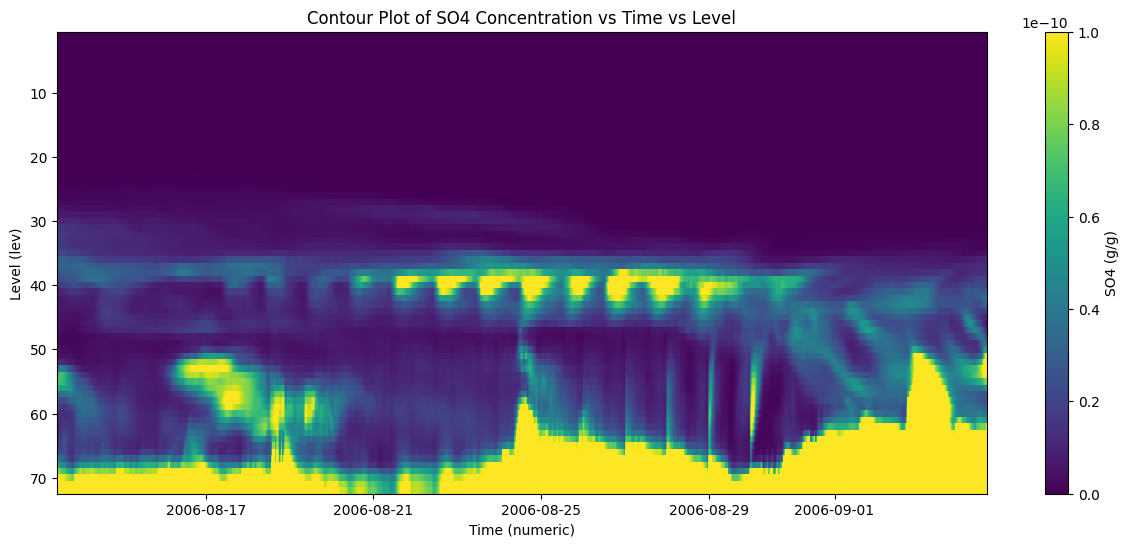

In [32]:
time_numeric = total_flux['time']
lev = total_flux['lev']

plt.figure(figsize=(15, 6))

contour = plt.pcolormesh(time_numeric, lev, total_flux.T,cmap='viridis', norm=mcolors.Normalize(vmin=0, vmax=1e-10))

plt.colorbar(contour, label='SO4 (g/g)')

# Labels and title
plt.xlabel('Time (numeric)')
plt.ylabel('Level (lev)')
plt.title('Contour Plot of SO4 Concentration vs Time vs Level')


plt.gca().invert_yaxis()

#plt.savefig('{stormname}_box{buffer}_'.format(stormname=stormname, buffer=2*bufferrr) + 'SO4_Concentration_vs_Time_vs_Level.png', bbox_inches='tight')


plt.show()

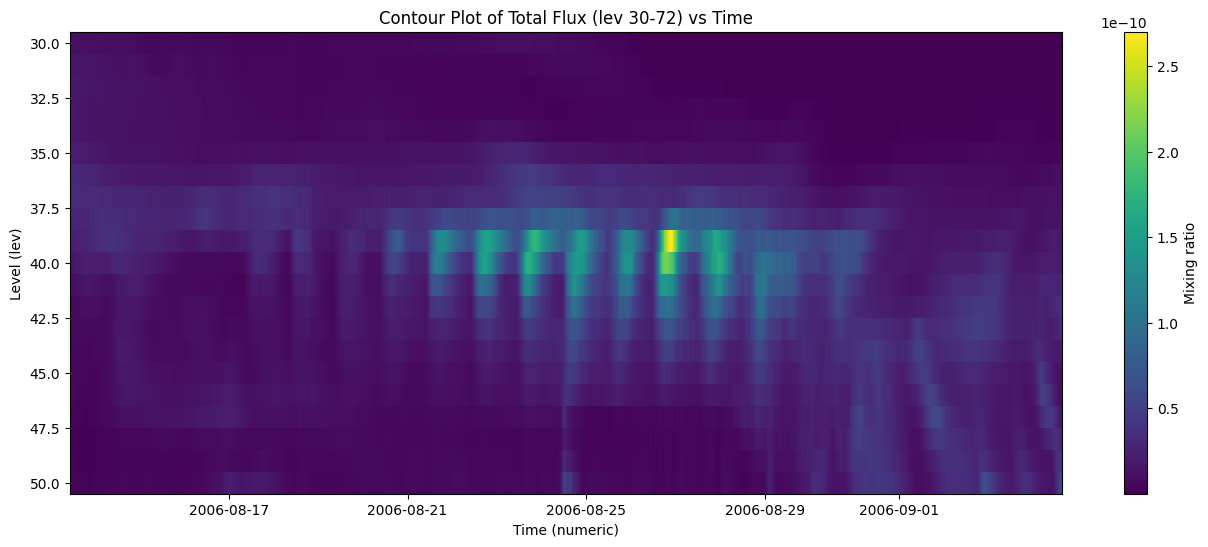

In [33]:

# Slice the DataArray for lev between 30 and 70
total_flux_da_sel = total_flux.sel(lev=slice(30, 50))

time_numeric = total_flux_da_sel['time']
lev_sel = total_flux_da_sel['lev']

plt.figure(figsize=(16, 6))

contour = plt.pcolormesh(time_numeric, lev_sel, total_flux_da_sel.T,cmap='viridis' )
#contour = plt.contourf(time_numeric, lev_sel, total_flux_da_sel.T,levels =10,cmap='viridis', norm=mcolors.CenteredNorm(vcenter=0) )

plt.colorbar(contour, label='Mixing ratio')


# plt.yscale('log')          # Uncomment for log scale
plt.gca().invert_yaxis()   # Uncomment to reverse the y-axis

# Labels and title
plt.xlabel('Time (numeric)')
plt.ylabel('Level (lev)')
plt.title('Contour Plot of Total Flux (lev 30-72) vs Time')

#plt.savefig('{stormname}_box{buffer}_'.format(stormname=stormname, buffer=2*bufferrr) + 'SO4_Concentration_vs_Time_vs_Level30_72.png', bbox_inches='tight')


plt.show()


In [34]:
minpres = stormtraj['minpres']
timee = stormtraj['time']

In [35]:
dspl['pl'].sel(time = extended_timee[1]).sel(lat = extended_minplat[1]).sel(lon = extended_minplon[1]).sel(lev= 40).values

array(13911.502, dtype=float32)

In [36]:
import numpy as np

# Determine the length of extended_time
n = len(extended_timee)

# Pre-allocate the array to store the selected values
extended_minpress = np.zeros(n)

# Loop over each index
for i in range(n):
    extended_minpress[i] = dspl['pl'].sel(
        time=extended_timee[i],
        lat=extended_minplat[i],
        lon=extended_minplon[i],
        lev=72
    ).item()

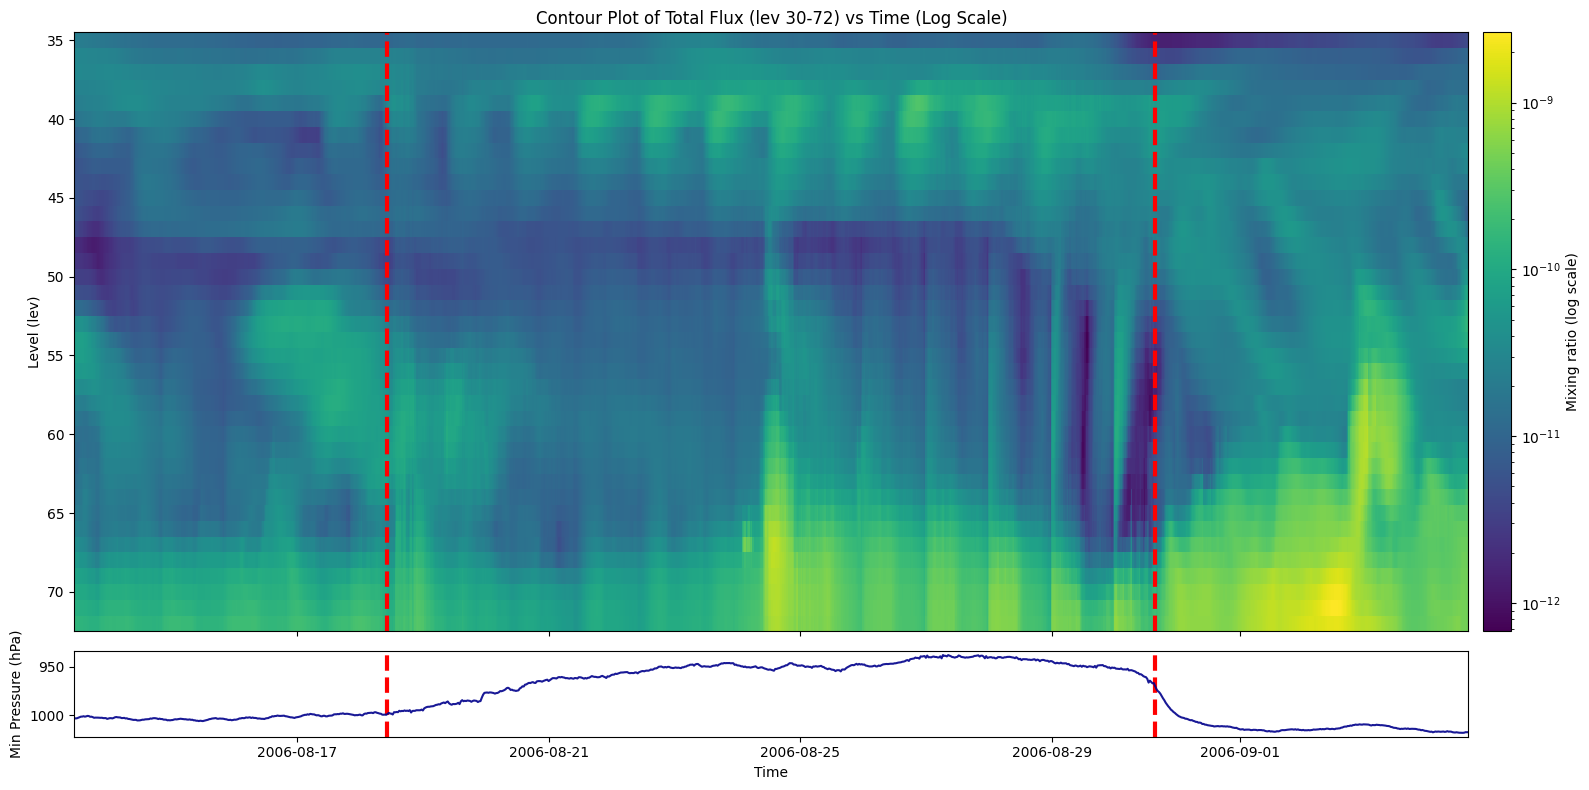

In [37]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors  # Import colors
from matplotlib import gridspec

# Slice the DataArray for lev between 30 and 70
total_flux_da_sel = total_flux.sel(lev=slice(35, 72))

time_numeric = total_flux_da_sel['time']
lev_sel = total_flux_da_sel['lev']

# Convert xarray time to numpy datetime
time_values = time_numeric.values  # Extract time values as numpy datetime64
storm_time_values = stormtraj['time']  # No need for .values

# Create figure with GridSpec
fig = plt.figure(figsize=(16, 8))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 0.02], height_ratios=[7, 1])

# Define axes: ax1 and ax2 share x-axis, cax is for colorbar
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
cax = fig.add_subplot(gs[0, 1])

# **Top Plot: Contour Plot for Total Flux with Logarithmic Scale**
flux_min = total_flux_da_sel.where(total_flux_da_sel > 0).min().item()  # Avoid zero values
flux_max = total_flux_da_sel.where(total_flux_da_sel > 0).max().item()
contour = ax1.pcolormesh(
    time_values, lev_sel, total_flux_da_sel.T, cmap='viridis',
    norm=mcolors.LogNorm(vmin= flux_min, vmax=flux_max)
)

ax1.set_ylabel('Level (lev)')
ax1.set_title('Contour Plot of Total Flux (lev 30-72) vs Time (Log Scale)')
ax1.invert_yaxis()  # Reverse y-axis for levels
ax1.set_xlabel('')  # Removes the x-axis label from ax1
ax1.tick_params(labelbottom=False)  # Hides tick labels on the x-axis of ax1

# Add vertical red lines at specified time steps
if len(time_values) > 5:
    ax1.axvline(time_values[239], color='red', linestyle='--', linewidth=3)
    ax1.axvline(time_values[-240], color='red', linestyle='--', linewidth=3)
    ax2.axvline(time_values[239], color='red', linestyle='--', linewidth=3)
    ax2.axvline(time_values[-240], color='red', linestyle='--', linewidth=3)

# Add colorbar in separate axes
fig.colorbar(contour, cax=cax, label='Mixing ratio (log scale)')

# **Bottom Plot: Line Plot for Minimum Pressure**
ax2.plot(extended_timee, extended_minpress / 100, color='darkblue', alpha=0.9)  # Convert Pa to hPa
ax2.set_ylabel('Min Pressure (hPa)')
ax2.set_xlabel('Time')
ax2.invert_yaxis()  # Pressure decreases upwards

# Set x-axis formatter on ax2 (since it displays the labels with sharex=True)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

# Ensure both plots share the same x-axis limits
ax2.set_xlim(time_values.min(), time_values.max())

# Adjust layout
plt.tight_layout()

# Save figure
#plt.savefig( f'{variable}_'+ f'{currentstorm}_'+ f'{stormname}' +'stacked_total_flux_min_pressure.png', bbox_inches='tight', transparent=True)

plt.show()


# Pressure based


In [38]:
lonsel

slice(-38, 4, None)

In [39]:
pl = dspl['pl'].sel(time= extended_timesel, lat= latsel, lon= lonsel)

In [40]:

plsel = []

# Loop through each time step
for t in range(len(extended_minplat)):
    
    plsell = dspl['pl'].sel( time= extended_timesel, lat = extended_minplat[t], lon = extended_minplon[t]).isel(time= t)
    
    plsel.append(plsell)


In [41]:
len(plsel)

1066

In [42]:
plsel_da = xr.DataArray(
        data=plsel,
        dims=['time', 'lev'],
        coords={
        'time': [plsel[t].time.values for t in range(len(plsel))],
        'lev': plsel[0].lev.values
        },
        name='plsel_da'
        )

In [43]:
plsel_da = plsel_da.isel(time=slice(1, None))

In [44]:
merged_ds = xr.merge([plsel_da, total_flux], compat='no_conflicts')

In [45]:
merged_ds

<xarray.Dataset> Size: 623kB
Dimensions:        (time: 1065, lev: 72)
Coordinates:
  * time           (time) datetime64[ns] 9kB 2006-08-13T11:00:00.000003 ... 2...
  * lev            (lev) float64 576B 1.0 2.0 3.0 4.0 ... 69.0 70.0 71.0 72.0
Data variables:
    plsel_da       (time, lev) float32 307kB 1.5 2.635 ... 1.002e+05 1.018e+05
    total_flux_da  (time, lev) float32 307kB 2.627e-18 3.219e-18 ... 4.395e-10

In [46]:
# experiment

In [47]:
merged_ds.sel(lev = 72).plsel_da.min()

<xarray.DataArray 'plsel_da' ()> Size: 4B
array(93805.81, dtype=float32)
Coordinates:
    lev      float64 8B 72.0

In [48]:
"""
Quick example: Interpolate flux data to pressure levels
"""
import xarray as xr
import numpy as np
from scipy.interpolate import interp1d

# Assuming your dataset is named 'ds'
# ds = your xarray Dataset

def quick_interpolate(ds):
    """
    Quick interpolation of total_flux_da to fixed pressure grid.
    Uses mean pressure at each level as the target grid.
    """
    # Extract data
    plsel = ds['plsel_da'].values  # (1065, 72)
    flux = ds['total_flux_da'].values  # (1065, 72)
    time = ds['time'].values
    
    # Define target pressure levels (mean at each level)
    target_pressures = np.mean(plsel, axis=0)  # (72,)
    
    # Initialize output
    flux_interp = np.zeros((len(time), len(target_pressures)))
    
    # Interpolate each time step
    for i in range(len(time)):
        # Sort by pressure (required for interpolation)
        sort_idx = np.argsort(plsel[i, :])
        p_sorted = plsel[i, sort_idx]
        f_sorted = flux[i, sort_idx]
        
        # Interpolate
        interp_func = interp1d(p_sorted, f_sorted, kind='linear',
                               bounds_error=False, fill_value=np.nan)
        flux_interp[i, :] = interp_func(target_pressures)
    
    # Create new dataset
    ds_new = xr.Dataset(
        data_vars={
            'total_flux': (['time', 'pressure'], flux_interp,
                          {'units': 'original_units', 
                           'long_name': 'Total flux interpolated to pressure levels'})
        },
        coords={
            'time': ('time', time),
            'pressure': ('pressure', target_pressures, 
                        {'units': 'Pa', 'long_name': 'Pressure level'})
        }
    )
    
    return ds_new

# Usage:
# ds_interpolated = quick_interpolate(ds)
# print(ds_interpolated)

# Access interpolated data:
# flux_on_pressure = ds_interpolated['total_flux']
# pressure_levels = ds_interpolated['pressure']

In [49]:
ds_interpolated = quick_interpolate(merged_ds)

In [50]:
new_ds = ds_interpolated

In [51]:
new_ds.to_netcdf('interpolated_Concentration_{variable}_{stormname}_box{buffer}_futures_extended_correctintrp.nc'.format(stormname=stormname, buffer=2*bufferrr, variable = variable))

In [52]:
# end exp

In [110]:
new_ds

<xarray.Dataset> Size: 622kB
Dimensions:     (time: 1065, pressure: 72)
Coordinates:
  * time        (time) datetime64[ns] 9kB 2006-08-13T11:00:00.000003 ... 2006...
  * pressure    (pressure) float32 288B 1.5 2.635 4.014 ... 9.645e+04 9.793e+04
Data variables:
    total_flux  (time, pressure) float64 613kB 3.291e-23 1.039e-22 ... 2.081e-10

In [52]:
bufferr = 5

In [53]:
from matplotlib.ticker import LogLocator

In [54]:
#new_ds = new_ds * (28.96/96.06) * 1e+6 # SO4

new_ds = new_ds * (28.96/64.066) * 1e+6 # SO2


In [55]:
new_ds.pressure/100

<xarray.DataArray 'pressure' (pressure: 72)> Size: 288B
array([1.50000015e-02, 2.63500866e-02, 4.01420780e-02, 5.67920916e-02,
       7.76719078e-02, 1.04524180e-01, 1.39599562e-01, 1.85422078e-01,
       2.44939953e-01, 3.21781933e-01, 4.20426935e-01, 5.46289623e-01,
       7.05946028e-01, 9.07285631e-01, 1.15998352e+00, 1.47563815e+00,
       1.86786151e+00, 2.35261726e+00, 2.94833064e+00, 3.67653775e+00,
       4.56164169e+00, 5.63185787e+00, 6.91830206e+00, 8.45629501e+00,
       1.02849903e+01, 1.24600315e+01, 1.50500965e+01, 1.81240902e+01,
       2.17610645e+01, 2.60492363e+01, 3.10892220e+01, 3.69925346e+01,
       4.39098930e+01, 5.20153847e+01, 6.14953041e+01, 7.25587082e+01,
       8.54397278e+01, 1.00513733e+02, 1.18249969e+02, 1.39116852e+02,
       1.63660324e+02, 1.92494003e+02, 2.26279770e+02, 2.65866241e+02,
       3.11607300e+02, 3.54447418e+02, 3.91369049e+02, 4.28264740e+02,
       4.65136566e+02, 5.01990662e+02, 5.38836121e+02, 5.75664062e+02,
       6.12485901e+02, 6.49301880e+02, 6.79972717e+02, 7.04507507e+02,
       7.29043701e+02, 7.53575928e+02, 7.78105957e+02, 8.00182861e+02,
       8.17355408e+02, 8.32070618e+02, 8.46782471e+02, 8.61500366e+02,
       8.76211548e+02, 8.90931335e+02, 9.05645020e+02, 9.20356506e+02,
       9.35070557e+02, 9.49788696e+02, 9.64494507e+02, 9.79255554e+02],
      dtype=float32)
Coordinates:
  * pressure  (pressure) float32 288B 1.5 2.635 4.014 ... 9.645e+04 9.793e+04

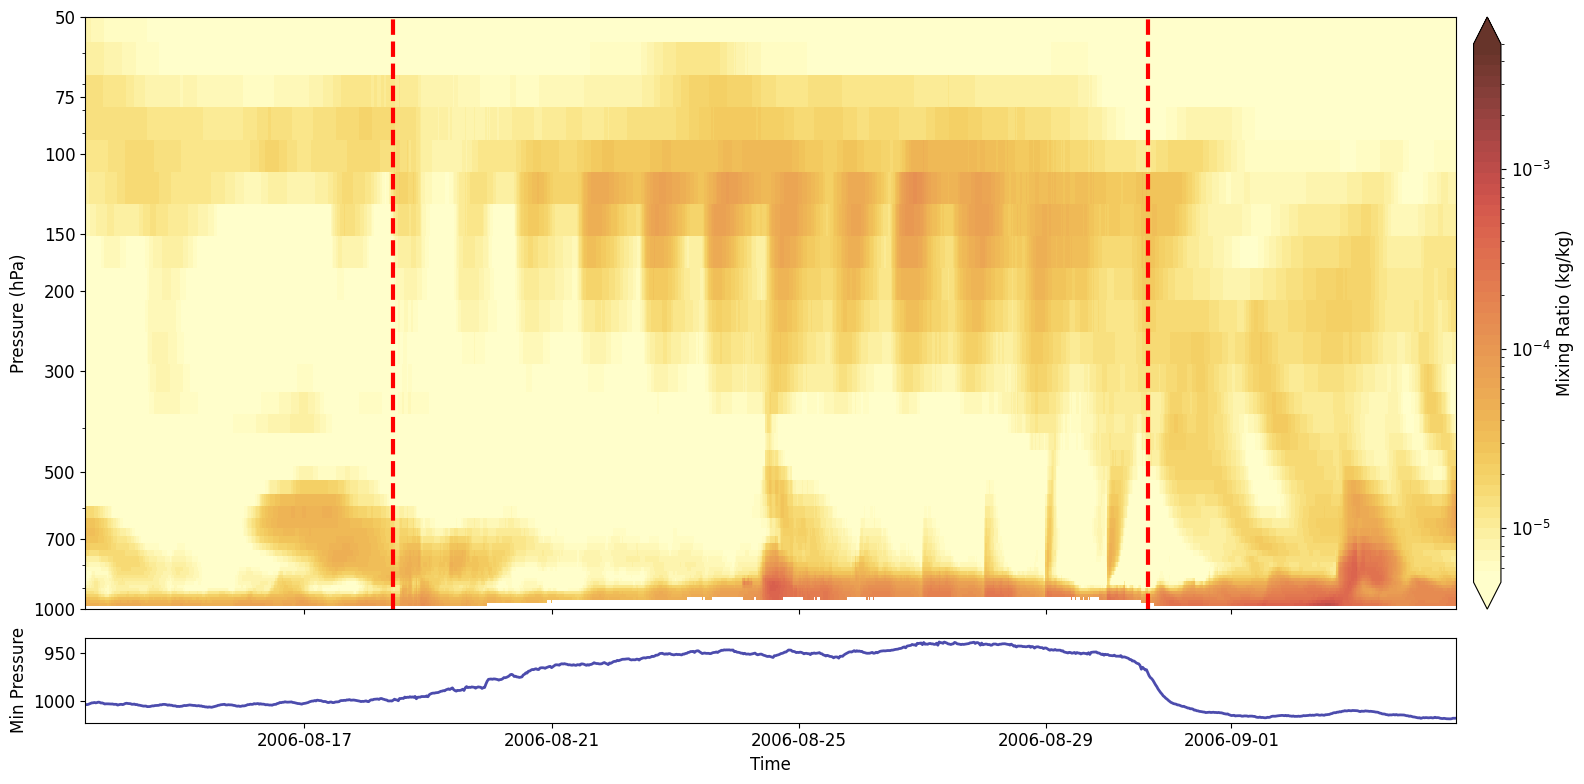

In [56]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import gridspec
from matplotlib.ticker import ScalarFormatter
import matplotlib as mpl
import colormaps as cmaps 
mpl.rcParams.update({'font.size': 12})  # Change 12 to your preferred base size


# Slice the DataArray for lev between 30 and 70
total_flux_da_sel = total_flux.sel(lev=slice(25, 72))

time_numeric = new_ds['time']
lev_sel = new_ds['pressure']

# Convert xarray time to numpy datetime
time_values = time_numeric.values  # Extract time values as numpy datetime64
storm_time_values = stormtraj['time']  # No need for .values

# Create figure with GridSpec
fig = plt.figure(figsize=(16, 8))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 0.02], height_ratios=[7, 1])

# Define axes: ax1 and ax2 share x-axis, cax is for colorbar
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
cax = fig.add_subplot(gs[0, 1])

# **Top Plot: Contour Plot for Total Flux**

so4_flux = new_ds.total_flux

flux_min = so4_flux.where(so4_flux > 5* 1e-6).min().item()  # Avoid zero values
flux_max = 5* 1e-3 #so4_flux.where(so4_flux > 0).max().item()


contour = ax1.pcolormesh(new_ds.time, new_ds.pressure /100, so4_flux.T, 
                 cmap=cmaps.lajolla_r.shift(-0.75), norm=mcolors.LogNorm(vmin= flux_min, vmax= flux_max),shading='nearest')

ax1.set_ylabel('Pressure (hPa)')
#ax1.set_title('Contour Plot of Total Flux (lev 30-72) vs Time')
ax1.set_ylim([50,1000])
ax1.invert_yaxis()  # Reverse y-axis for levels
ax1.set_yscale('log')


# Define major and minor ticks for the logarithmic scale
ax1.yaxis.set_major_locator(LogLocator(base=10.0, subs=None, numticks=10))  # Major ticks at powers of 10
ax1.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))  # Minor ticks

# Explicitly set y-ticks at custom pressure levels
custom_ticks = [1000, 700, 500, 300, 200, 150, 100, 75, 50]
ax1.set_yticks(custom_ticks)
ax1.set_yticklabels([str(int(tick)) for tick in custom_ticks])  # Convert to string labels




ax1.set_xlabel('')  # Removes the x-axis label from ax1
ax1.tick_params(labelbottom=False)  # Hides tick labels on the x-axis of ax1



# Add vertical red lines at specified time steps
if len(time_values) > 5:
    ax1.axvline(time_values[239], color='red', linestyle='--', linewidth=3)
    ax1.axvline(time_values[-240], color='red', linestyle='--', linewidth=3)

# Add colorbar in separate axes
fig.colorbar(contour, cax=cax, label='Mixing Ratio (kg/kg)', extend='both')

# **Bottom Plot: Line Plot for Minimum Pressure**
ax2.plot(extended_timee, extended_minpress / 100, color='darkblue', alpha=0.7,  linewidth=2)  # Convert Pa to hPa
ax2.set_ylabel('Min Pressure')
ax2.set_xlabel('Time')
ax2.invert_yaxis()  # Pressure decreases upwards


# Set x-axis formatter on ax2 (since it displays the labels with sharex=True)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

# Ensure both plots share the same x-axis limits
ax2.set_xlim(time_values.min(), time_values.max())


# Adjust layout
plt.tight_layout()

from matplotlib.ticker import LogLocator


buffer = 5

# Save figure
#plt.savefig(f'{stormname}_Box{buffer}_' + 'bcphobic_Concentration_vs_Time_vs_Pressure_extended.png', bbox_inches='tight', transparent=True)

plt.show()

In [53]:
from datetime import datetime

# Set custom x-axis limits (replace with your desired dates)
x_min = datetime(2023, 1, 1)  # Example start date
x_max = datetime(2023, 12, 31)  # Example end date
ax2.set_xlim(x_min, x_max)

(19358.0, 19722.0)